In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
#Set data path for paysim.csv
data_path = Path("C:/Users/durel/Documents/Python Programming - Wfu/Personal Projects/aml-rule-engine/data/paysimdataset.csv")

In [3]:
#import csv
df = pd.read_csv(data_path)

In [4]:
#Check the data type of each column
print("Column Data Types:")
print(df.dtypes)

#Check the data for null values
print("\nNull Value Check:")
print(df.isnull().sum())

print("\nBasic Shape:")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")

Column Data Types:
step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Null Value Check:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Basic Shape:
Rows: 6,362,620 | Columns: 11


Transaction Type Counts
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

Fraud by Transaction Type:
type
CASH_OUT    4116
TRANSFER    4097
CASH_IN        0
DEBIT          0
PAYMENT        0
Name: isFraud, dtype: int64


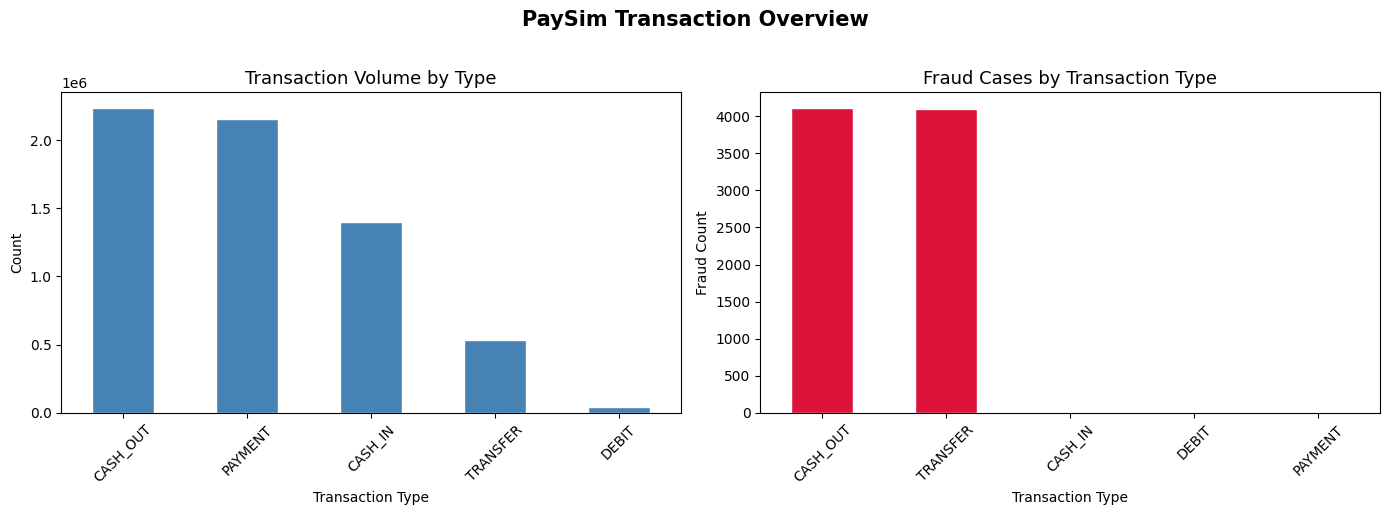

In [5]:
# Count how many transactions exist per type
type_counts = df['type'].value_counts()
print("Transaction Type Counts")
print(type_counts)

print("\nFraud by Transaction Type:")
# Group by type and sum isFraud to see which types carry actual fraud
# This will directly inform which types my rules should target
fraud_by_type = df.groupby('type')['isFraud'].sum().sort_values(ascending=False)
print(fraud_by_type)

# Plot both side by side for the portfolio notebook
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: overall volume by transaction type
type_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Transaction Volume by Type', fontsize=13)
axes[0].set_xlabel('Transaction Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Right plot: fraud cases by transaction type
fraud_by_type.plot(kind='bar', ax=axes[1], color='crimson', edgecolor='white')
axes[1].set_title('Fraud Cases by Transaction Type', fontsize=13)
axes[1].set_xlabel('Transaction Type')
axes[1].set_ylabel('Fraud Count')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('PaySim Transaction Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/reports/transaction_type_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Finding: Fraud Concentration

All 8,213 confirmed fraud cases in PaySim are concentrated in two transaction types:
- TRANSFER: 4,097 cases
- CASH_OUT: 4,116 cases

CASH_IN, DEBIT, and PAYMENT have zero fraud cases.

**Rule engine implication:** All four AML rules (structuring, rapid movement, 
velocity spikes, dormant account activity) will pre-filter to TRANSFER and 
CASH_OUT transactions only. This reduces noise and false positives before 
any rule logic is applied.

In [6]:
# This cell documents which columns each rule depends on
# Serves as a reference for rules.py later on

rule_column_map = {
    'Structuring': {
        'columns': ['nameOrig', 'amount', 'step', 'type'],
        'logic': 'Multiple transactions just below a reporting threshold (e.g. 10,000) by the same sender'
    },
    'Rapid Movement': {
        'columns': ['nameOrig', 'nameDest', 'amount', 'step', 'type'],
        'logic': 'Funds transferred and immediately moved again within a short time window'
    },
    'Velocity Spike': {
        'columns': ['nameOrig', 'step', 'amount', 'type'],
        'logic': 'Sudden increase in transaction frequency or volume vs the accounts historical baseline'
    },
    'Dormant Account Activity': {
        'columns': ['nameOrig', 'step', 'amount', 'type', 'oldbalanceOrg'],
        'logic': 'Account with no activity for an extended period suddenly initiates large transactions'
    }
}

# Print the mapping
for rule, details in rule_column_map.items():
    print(f"Rule: {rule}")
    print(f"  Columns : {', '.join(details['columns'])}")
    print(f"  Logic   : {details['logic']}")
    print()

Rule: Structuring
  Columns : nameOrig, amount, step, type
  Logic   : Multiple transactions just below a reporting threshold (e.g. 10,000) by the same sender

Rule: Rapid Movement
  Columns : nameOrig, nameDest, amount, step, type
  Logic   : Funds transferred and immediately moved again within a short time window

Rule: Velocity Spike
  Columns : nameOrig, step, amount, type
  Logic   : Sudden increase in transaction frequency or volume vs the accounts historical baseline

Rule: Dormant Account Activity
  Columns : nameOrig, step, amount, type, oldbalanceOrg
  Logic   : Account with no activity for an extended period suddenly initiates large transactions



AML-relevant transactions: 2,770,409 of 6,362,620 total


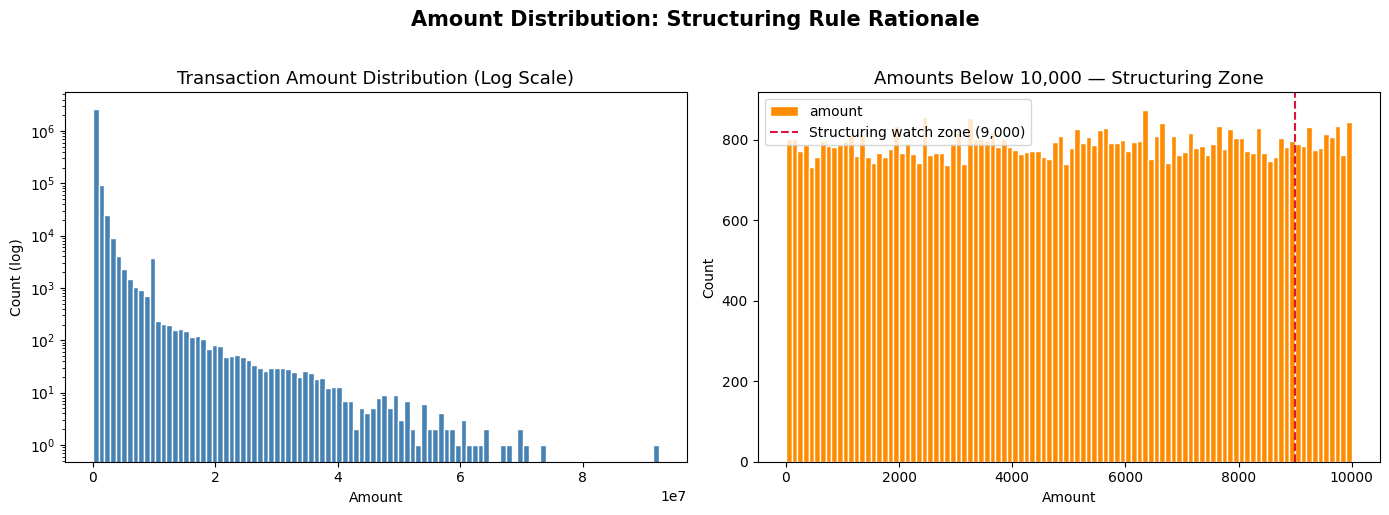


Transactions between 9,000 and 10,000: 8,020


In [7]:
# Filter to only the transaction types where fraud exists
# Established in Cell 3 that only TRANSFER and CASH_OUT carry fraud
aml_df = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()

print(f"AML-relevant transactions: {len(aml_df):,} of {len(df):,} total")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: full amount distribution on log scale
# Using log scale here since PaySim amounts span several orders of magnitude
aml_df['amount'].plot(
    kind='hist',
    bins=100,
    ax=axes[0],
    color='steelblue',
    edgecolor='white',
    log=True
)
axes[0].set_title('Transaction Amount Distribution (Log Scale)', fontsize=13)
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Count (log)')

# Right plot: zoomed in below $10,000
# Structuring means deliberately keeping transactions just under reporting thresholds
# The most common threshold in AML is $10,000 (based on US Bank Secrecy Act)
below_threshold = aml_df[aml_df['amount'] < 10_000]
below_threshold['amount'].plot(
    kind='hist',
    bins=100,
    ax=axes[1],
    color='darkorange',
    edgecolor='white'
)
axes[1].axvline(x=9_000, color='crimson', linestyle='--', linewidth=1.5,
                label='Structuring watch zone (9,000)')
axes[1].legend()
axes[1].set_title('Amounts Below 10,000 — Structuring Zone', fontsize=13)
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Count')

plt.suptitle('Amount Distribution: Structuring Rule Rationale', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/reports/structuring_rationale.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTransactions between 9,000 and 10,000: "
      f"{len(aml_df[(aml_df['amount'] >= 9_000) & (aml_df['amount'] < 10_000)]):,}")

## Structuring Rule Rationale

8,020 transactions fall between 9,000 and 10,000 in TRANSFER and CASH_OUT types.
Structuring detection will flag accounts that make multiple transactions in this 
window within a defined time period, indicating deliberate threshold avoidance.

**Rule parameter preview:** amount >= 9,000 AND amount < 10,000, 
grouped by sender, within a rolling time window.

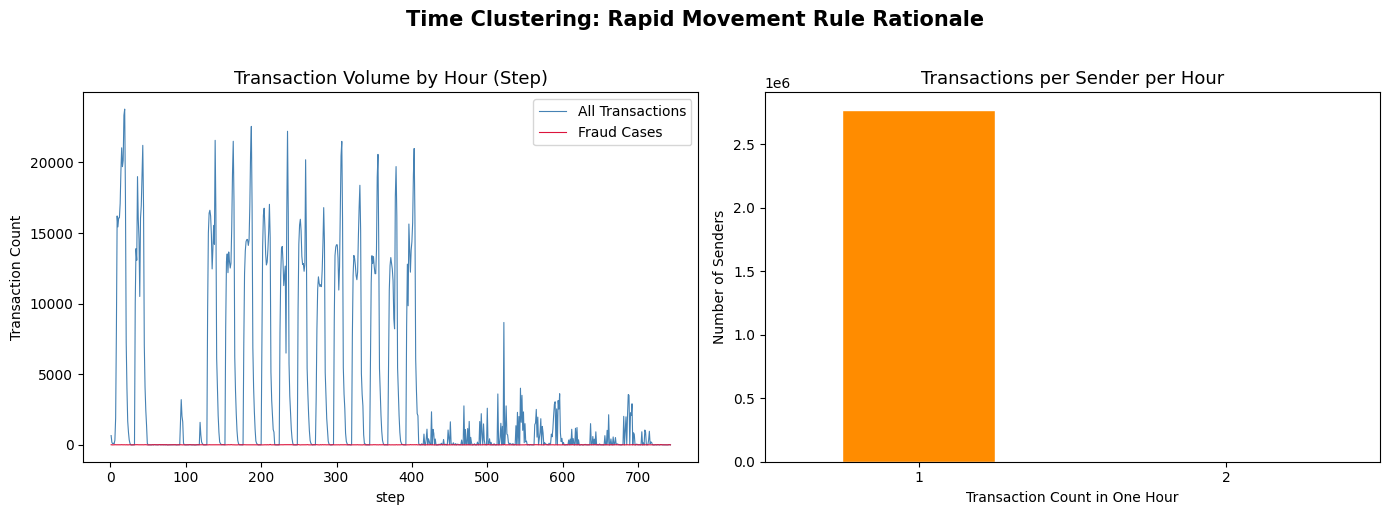

Max transactions by one sender in a single hour: 2


In [8]:
# 'step' in PaySim represents hours elapsed since simulation start
# We use it as our time dimension for detecting rapid sequential transactions
# Rapid movement: funds transferred out quickly after being received

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: transaction volume by hour across the full simulation
# Shows natural peaks: rapid movement will spike above this baseline
hourly_volume = aml_df.groupby('step').size()
hourly_volume.plot(ax=axes[0], color='steelblue', linewidth=0.8)
axes[0].set_title('Transaction Volume by Hour (Step)', fontsize=13)
axes[0].set_xlabel('Step (Hour)')
axes[0].set_ylabel('Transaction Count')

# Left plot: overlay of fraud cases by hour to see if fraud clusters in time
fraud_hourly = aml_df[aml_df['isFraud'] == 1].groupby('step').size()
fraud_hourly.plot(ax=axes[0], color='crimson', linewidth=0.8, label='Fraud')
axes[0].legend(['All Transactions', 'Fraud Cases'])

# Right plot: how many transactions does each sender make per step?
# High counts per sender per hour is the signal for rapid movement
tx_per_sender_per_step = (
    aml_df.groupby(['step', 'nameOrig'])
    .size()
    .reset_index(name='tx_count')
)

# Plot distribution of how many transactions senders make in a single hour
tx_per_sender_per_step['tx_count'].value_counts().sort_index().head(10).plot(
    kind='bar',
    ax=axes[1],
    color='darkorange',
    edgecolor='white'
)
axes[1].set_title('Transactions per Sender per Hour', fontsize=13)
axes[1].set_xlabel('Transaction Count in One Hour')
axes[1].set_ylabel('Number of Senders')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Time Clustering: Rapid Movement Rule Rationale',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/reports/rapid_movement_rationale.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the max transactions any single sender made in one hour
max_tx = tx_per_sender_per_step['tx_count'].max()
print(f"Max transactions by one sender in a single hour: {max_tx}")

## Rapid Movement Rule Rationale — Revised Approach

PaySim senders make at most 2 transactions per hour, so frequency-based 
detection within a single step has limited indications.

Instead, the rapid movement rule will detect **transaction chaining**:
A sender receives funds and forwards them within a short step window.
This reflects layering behavior such as moving money through intermediary accounts
to obscure its origin.

**Rule parameter preview:** nameDest appears as nameOrig within N steps,
with amount correlation indicating pass-through behavior.

Sender Velocity Distribution
           total_tx  steps_active  avg_tx_per_step
count  2.768630e+06  2.768630e+06     2.768630e+06
mean   1.000643e+00  1.000638e+00     1.000005e+00
std    2.538327e-02  2.529073e-02     2.166897e-03
min    1.000000e+00  1.000000e+00     1.000000e+00
25%    1.000000e+00  1.000000e+00     1.000000e+00
50%    1.000000e+00  1.000000e+00     1.000000e+00
75%    1.000000e+00  1.000000e+00     1.000000e+00
max    3.000000e+00  3.000000e+00     2.000000e+00


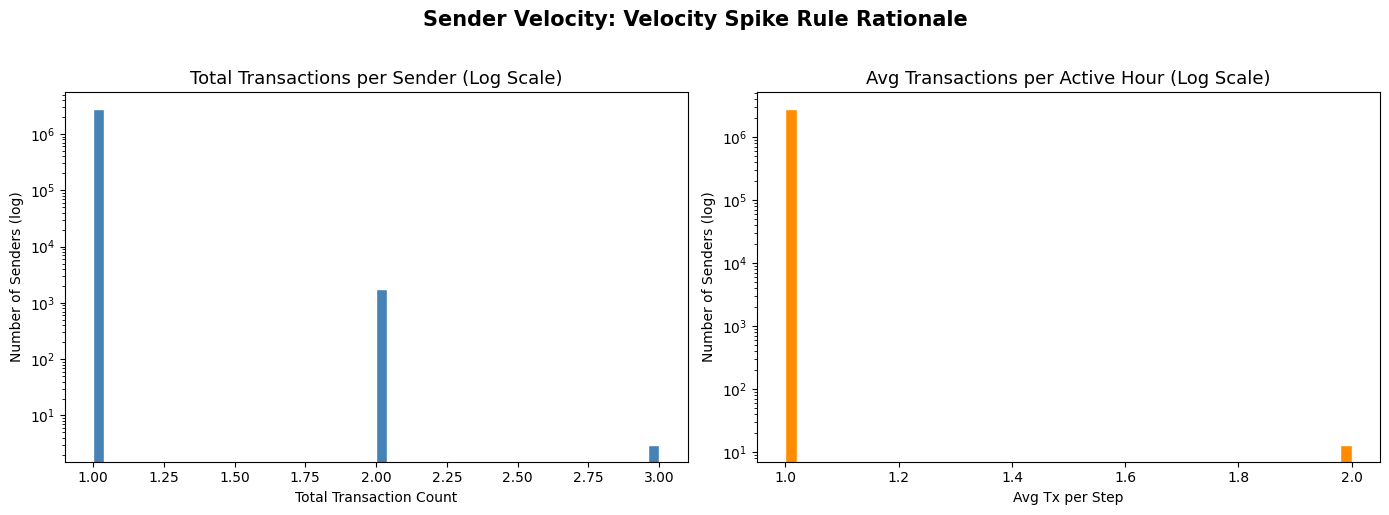

In [9]:
# Velocity spike: an account suddenly transacts far more than its own historical baseline
# We measure this by looking at how active each sender is across the full simulation

# Count total transactions per sender across all steps
sender_velocity = (
    aml_df.groupby('nameOrig')
    .agg(
        total_tx=('amount', 'count'),       # how many transactions they made total
        total_amount=('amount', 'sum'),      # total value moved
        steps_active=('step', 'nunique')     # how many unique hours they were active
    )
    .reset_index()
)

# Compute average transactions per active hour for each sender
# This becomes each account's personal baseline in the rule engine
sender_velocity['avg_tx_per_step'] = (
    sender_velocity['total_tx'] / sender_velocity['steps_active']
)

print("Sender Velocity Distribution")
print(sender_velocity[['total_tx', 'steps_active', 'avg_tx_per_step']].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: distribution of total transactions per sender
# Most senders are low frequency. This shows that spikes above this are anomalous
sender_velocity['total_tx'].plot(
    kind='hist',
    bins=50,
    ax=axes[0],
    color='steelblue',
    edgecolor='white',
    log=True
)
axes[0].set_title('Total Transactions per Sender (Log Scale)', fontsize=13)
axes[0].set_xlabel('Total Transaction Count')
axes[0].set_ylabel('Number of Senders (log)')

# Right plot: distribution of average transactions per active hour
# Senders far above this distribution are velocity spike candidates
sender_velocity['avg_tx_per_step'].plot(
    kind='hist',
    bins=50,
    ax=axes[1],
    color='darkorange',
    edgecolor='white',
    log=True
)
axes[1].set_title('Avg Transactions per Active Hour (Log Scale)', fontsize=13)
axes[1].set_xlabel('Avg Tx per Step')
axes[1].set_ylabel('Number of Senders (log)')

plt.suptitle('Sender Velocity: Velocity Spike Rule Rationale',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/reports/velocity_spike_rationale.png', dpi=150, bbox_inches='tight')
plt.show()

## Velocity Spike Rule Rationale — Revised Approach

75% of senders make exactly 1 transaction in PaySim. Personal baseline 
comparison has no variance to exploit.

Instead, the velocity spike rule will flag accounts where:
- Transaction count > 1 within the simulation, AND
- Aggregate amount moved exceeds a threshold

This combines frequency and value into a composite risk signal, 
reflecting accounts that are both unusually active and moving 
significant funds.

**Rule parameter preview:** sender tx_count > 1 AND total_amount 
exceeds the 95th percentile of sender aggregate amounts.

Dormant account candidates: 1,094

Sample dormant candidates:
          nameOrig  first_step  last_step  step_span  tx_count  first_amount
1540   C1001064466         138        469        331         2      49421.26
2901   C1002027777         379        567        188         2       8373.83
5429     C10037435         235        402        167         2     392937.78
7117   C1004939913           9        259        250         2     733478.62
8110   C1005646800          21        184        163         2     156163.47
9105   C1006323448          19        251        232         2     356995.42
11097  C1007743787          34        395        361         2     333975.35
20157  C1014032942         299        595        296         2     397482.56
23165   C101617638          16        405        389         2     187367.79
24249  C1016949303          20        358        338         2     111820.18


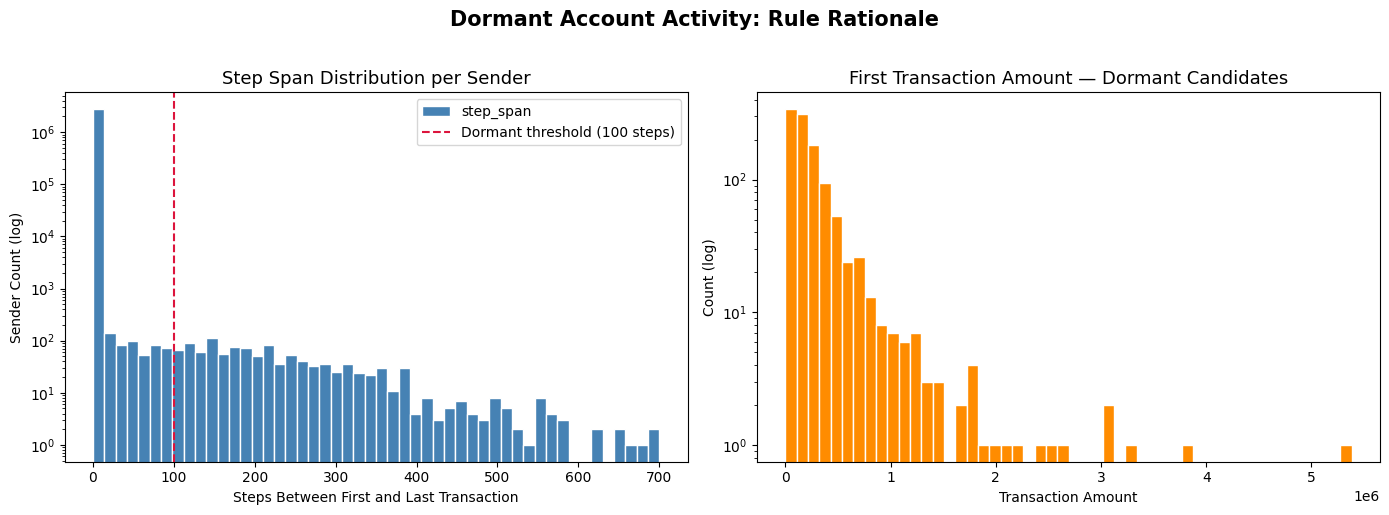

In [10]:
# Dormant account: an account that is inactive for a long period
# then suddenly initiates a large transaction
# In PaySim, 'step' is our time axis and 'oldbalanceOrg' tells us
# if an account had funds sitting idle

# Find each sender's first and last transaction step
sender_activity = (
    aml_df.groupby('nameOrig')
    .agg(
        first_step=('step', 'min'),       # earliest transaction hour
        last_step=('step', 'max'),        # latest transaction hour
        tx_count=('amount', 'count'),     # total transactions
        first_amount=('amount', 'first'), # amount of their first transaction
        avg_balance=('oldbalanceOrg', 'mean') # average pre-transaction balance
    )
    .reset_index()
)

# Compute the gap between first and last transaction
# A large gap with only 1-2 transactions suggests dormant then suddenly active
sender_activity['step_span'] = (
    sender_activity['last_step'] - sender_activity['first_step']
)

# Dormant candidates: accounts with a long gap between first and last step
# but very few total transactions means they sat idle then made a move
dormant_candidates = sender_activity[
    (sender_activity['step_span'] > 100) &  # inactive for 100+ hours
    (sender_activity['tx_count'] <= 2)       # but made very few transactions
]

print(f"Dormant account candidates: {len(dormant_candidates):,}")
print(f"\nSample dormant candidates:")
print(dormant_candidates[['nameOrig', 'first_step', 'last_step', 
                           'step_span', 'tx_count', 'first_amount']].head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: distribution of step span across all senders
# Senders with large spans but low tx_count are the dormant targets
sender_activity['step_span'].plot(
    kind='hist',
    bins=50,
    ax=axes[0],
    color='steelblue',
    edgecolor='white',
    log=True
)
axes[0].axvline(x=100, color='crimson', linestyle='--', 
                linewidth=1.5, label='Dormant threshold (100 steps)')
axes[0].set_title('Step Span Distribution per Sender', fontsize=13)
axes[0].set_xlabel('Steps Between First and Last Transaction')
axes[0].set_ylabel('Sender Count (log)')
axes[0].legend()

# Right plot: dormant candidates by first transaction amount
# Large first amounts after long inactivity should be a great
# single to look at for AML
dormant_candidates['first_amount'].plot(
    kind='hist',
    bins=50,
    ax=axes[1],
    color='darkorange',
    edgecolor='white',
    log=True
)
axes[1].set_title('First Transaction Amount — Dormant Candidates', fontsize=13)
axes[1].set_xlabel('Transaction Amount')
axes[1].set_ylabel('Count (log)')

plt.suptitle('Dormant Account Activity: Rule Rationale',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/reports/dormant_account_rationale.png', dpi=150, bbox_inches='tight')
plt.show()

## Dormant Account Rule Rationale

1,094 accounts show dormant behavior: inactive for 100+ steps then 
initiating 1-2 large transactions. First transaction amounts range 
from thousands to over 700,000, suggesting these are not routine 
reactivations.

**Rule parameter preview:** step_span > 100 AND tx_count <= 2 
AND first_amount exceeds a minimum threshold (TBD in Phase 2).
The minimum amount threshold will filter out low-value reactivations 
that are unlikely to be AML-relevant.

In [11]:
# Define the database path
db_path = Path("C:/Users/durel/Documents/Python Programming - Wfu/Personal Projects/aml-rule-engine/data/aml_engine.db")

# Connect to SQLite
conn = sqlite3.connect(db_path)

print(f"Writing {len(aml_df):,} rows to SQLite...")

# Create a table called 'transactions' from the aml_df dataframe
# aml_df is already filtered to TRANSFER and CASH_OUT only
aml_df.to_sql(
    name='transactions',
    con=conn,
    if_exists='replace',  # drop and recreate table on each run
    index=False           # don't write the pandas index as a column
)

# Verify the write was successful by querying row_count
row_count = pd.read_sql("SELECT COUNT(*) as total FROM transactions", conn)
print(f"Rows written to SQLite: {row_count['total'].values[0]:,}")

# Preview the table structure from SQLite's perspective
preview = pd.read_sql("SELECT * FROM transactions LIMIT 5", conn)
print("\n=== SQLite Table Preview ===")
print(preview)

conn.close()
print("\nDatabase connection closed. File saved to ../data/aml_engine.db")

Writing 2,770,409 rows to SQLite...
Rows written to SQLite: 2,770,409

=== SQLite Table Preview ===
   step      type     amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1  TRANSFER     181.00  C1305486145          181.0             0.0   
1     1  CASH_OUT     181.00   C840083671          181.0             0.0   
2     1  CASH_OUT  229133.94   C905080434        15325.0             0.0   
3     1  TRANSFER  215310.30  C1670993182          705.0             0.0   
4     1  TRANSFER  311685.89  C1984094095        10835.0             0.0   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0   C553264065             0.0            0.00        1               0  
1    C38997010         21182.0            0.00        1               0  
2   C476402209          5083.0        51513.44        0               0  
3  C1100439041         22425.0            0.00        0               0  
4   C932583850          6267.0      2719172.89        0               0  

In [ ]:
# src/ingest.py
# Reusable ingestion module for the AML Rule Engine
# Called by the Streamlit app and any other scripts
# Central path configuration: all paths are defined once here
# Using Path() keeps this portable across operating systems
DATA_DIR = Path(__file__).resolve().parent.parent / "data"
CSV_PATH = DATA_DIR / "paysim.csv"
DB_PATH = DATA_DIR / "aml_engine.db"

# Only TRANSFER and CASH_OUT carry fraud signal in PaySim
# Established during EDA in 01_ingest_and_explore.ipynb
AML_RELEVANT_TYPES = ['TRANSFER', 'CASH_OUT']

In [ ]:
def load_raw_data(csv_path: Path = CSV_PATH) -> pd.DataFrame:
    """
    Load the raw PaySim CSV into a DataFrame.
    Returns the full unfiltered dataset.
    """
    # Verify the file exists before attempting to load
    if not csv_path.exists():
        raise FileNotFoundError(f"PaySim CSV not found at: {csv_path}")
    
    df = pd.read_csv(csv_path)
    print(f"[ingest] Loaded {len(df):,} rows from {csv_path.name}")
    return df


def filter_aml_relevant(df: pd.DataFrame) -> pd.DataFrame:
    """
    Filter raw PaySim data to AML-relevant transaction types only.
    Retains TRANSFER and CASH_OUT — the only types with confirmed fraud signal.
    Established in EDA: Cell 3 of 01_ingest_and_explore.ipynb
    """
    # Apply the type filter established during EDA
    aml_df = df[df['type'].isin(AML_RELEVANT_TYPES)].copy()
    
    print(f"[ingest] Filtered to {len(aml_df):,} AML-relevant rows "
          f"({len(aml_df)/len(df)*100:.1f}% of total)")
    
    return aml_df